# Rainfall Classification - Exploratory Data Analysis

This notebook performs EDA on the Phnom Penh weather dataset to understand patterns before building a classification model.

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif, f_classif
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

COLORS = ['#2ecc71', '#f39c12', '#e74c3c']
LABELS = {0: 'No Rain', 1: 'Light Rain', 2: 'Heavy Rain'}

In [4]:
df = pd.read_csv('phnom_penh_weather_processed.csv')
print(f"Dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")

Dataset: 62,808 rows, 40 columns
Missing values: 0
Duplicates: 0


In [5]:
df.head()

,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,weather_code,pressure_msl,surface_pressure,cloud_cover,cloud_cover_low,cloud_cover_mid,...,rain_class,temperature_2m_roll3,temperature_2m_roll6,relative_humidity_2m_roll3,relative_humidity_2m_roll6,surface_pressure_roll3,surface_pressure_roll6,temp_humidity,pressure_temp,temp_diff
0,0.322967,0.495659,0.055046,0.079003,0.046154,0.881579,0.766569,1.0,0.066667,0.0,...,0,0.294309,0.24433,0.496386,0.506688,0.758478,0.760502,0.375111,0.329776,0.3875
1,0.301435,0.491696,0.009174,0.049617,0.046154,0.855263,0.746633,1.0,0.000000,0.0,...,0,0.294309,0.24433,0.496386,0.506688,0.758478,0.760502,0.356284,0.307333,0.3900
2,0.279904,0.503532,0.000000,0.027489,0.046154,0.848684,0.741552,1.0,0.000000,0.0,...,0,0.294309,0.24433,0.496386,0.506688,0.758478,0.760502,0.352918,0.285257,0.3725
3,0.253589,0.528901,0.000000,0.000000,0.046154,0.809211,0.711650,1.0,0.000000,0.0,...,0,0.270732,0.24433,0.507658,0.506688,0.739680,0.760502,0.358558,0.257737,0.3450
4,0.232057,0.547006,0.000000,0.000000,0.046154,0.802632,0.706588,1.0,0.000000,0.0,...,0,0.247154,0.24433,0.526412,0.506688,0.725972,0.760502,0.359877,0.235681,0.3225


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
temperature_2m,62808.0,0.455962,0.142607,0.0,0.351077,0.433014,0.552632,1.0
relative_humidity_2m,62808.0,0.669955,0.210793,0.0,0.524882,0.701393,0.847443,1.0
dew_point_2m,62808.0,0.547731,0.222170,0.0,0.426606,0.628440,0.711009,1.0
apparent_temperature,62808.0,0.496974,0.205333,0.0,0.375000,0.487849,0.625000,1.0
weather_code,62808.0,0.219605,0.337845,0.0,0.030769,0.046154,0.046154,1.0
pressure_msl,62808.0,0.502824,0.177049,0.0,0.375000,0.493421,0.625000,1.0
surface_pressure,62808.0,0.482038,0.133611,0.0,0.386828,0.475628,0.573246,1.0
cloud_cover,62808.0,0.745593,0.339085,0.0,0.520000,0.950000,1.000000,1.0
cloud_cover_low,62808.0,0.251525,0.329178,0.0,0.000000,0.100000,0.400000,1.0
cloud_cover_mid,62808.0,0.282277,0.332589,0.0,0.016393,0.147541,0.409836,1.0


## 2. Target Distribution

First thing to check in any classification problem - how balanced are the classes?

In [7]:
counts = df['rain_class'].value_counts().sort_index()
print("Class Distribution:")
for cls in [0, 1, 2]:
    pct = counts[cls] / len(df) * 100
    print(f"  {LABELS[cls]}: {counts[cls]:,} ({pct:.1f}%)")
print(f"\nImbalance ratio: {counts.max()/counts.min():.1f}x")

Class Distribution:
  No Rain: 47,944 (76.3%)
  Light Rain: 7,632 (12.2%)
  Heavy Rain: 7,232 (11.5%)

Imbalance ratio: 6.6x


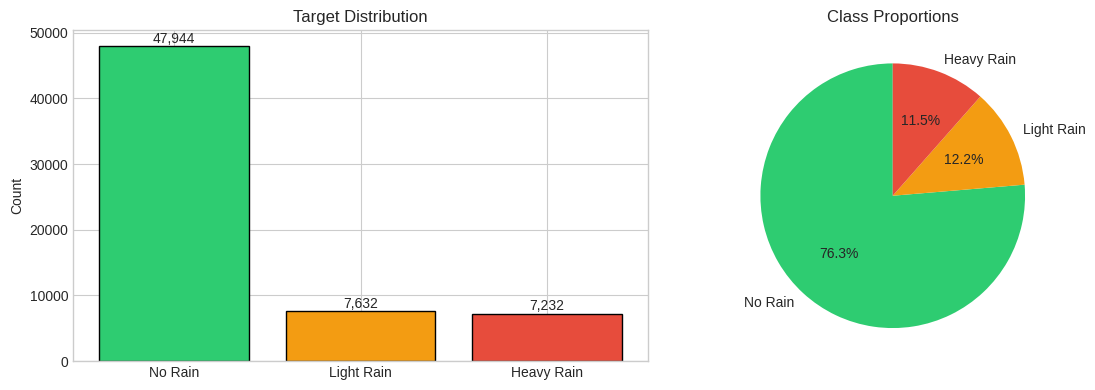

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels = [LABELS[i] for i in [0, 1, 2]]

axes[0].bar(labels, counts.values, color=COLORS, edgecolor='black')
axes[0].set_ylabel('Count')
axes[0].set_title('Target Distribution')
for i, (c, v) in enumerate(zip(labels, counts.values)):
    axes[0].text(i, v + 500, f'{v:,}', ha='center')

axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%', colors=COLORS, startangle=90)
axes[1].set_title('Class Proportions')

plt.tight_layout()
plt.show()

The dataset is imbalanced. No Rain dominates at 76%, while rain classes are around 12% each. This means we'll need to use techniques like SMOTE or class weights during modeling.

## 3. Feature Distributions by Class

Let's see how key weather features differ between rain and no-rain conditions.

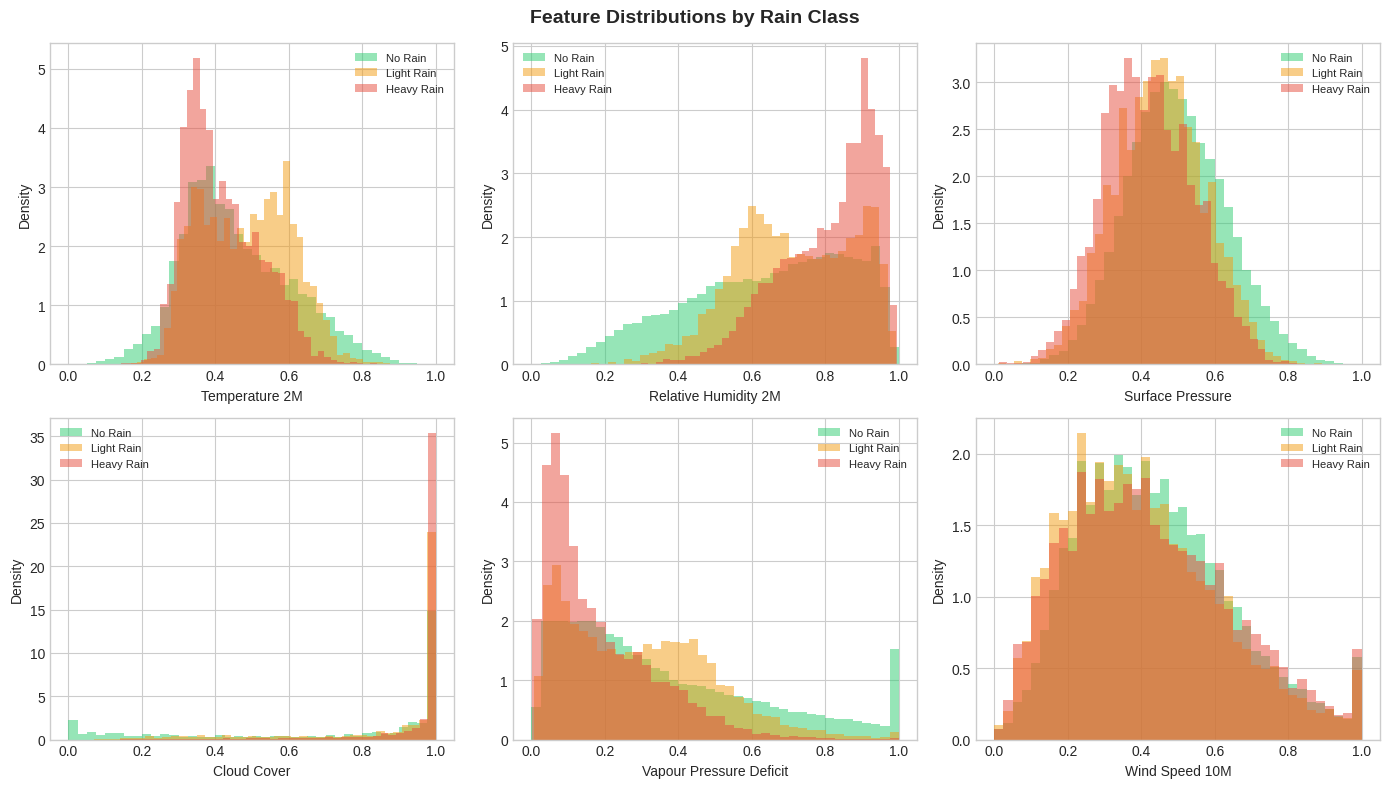

In [9]:
features = ['temperature_2m', 'relative_humidity_2m', 'surface_pressure',
            'cloud_cover', 'vapour_pressure_deficit', 'wind_speed_10m']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, col in enumerate(features):
    ax = axes[idx]
    for cls in [0, 1, 2]:
        data = df[df['rain_class'] == cls][col]
        ax.hist(data, bins=40, alpha=0.5, label=LABELS[cls], color=COLORS[cls], density=True)
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions by Rain Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Key observations:
- Humidity shifts right (higher) when it rains
- Cloud cover is much higher during rain
- Vapour pressure deficit is lower during rain
- Temperature and wind speed show less separation

## 4. Box Plots Comparison

A cleaner view of how features vary across classes.

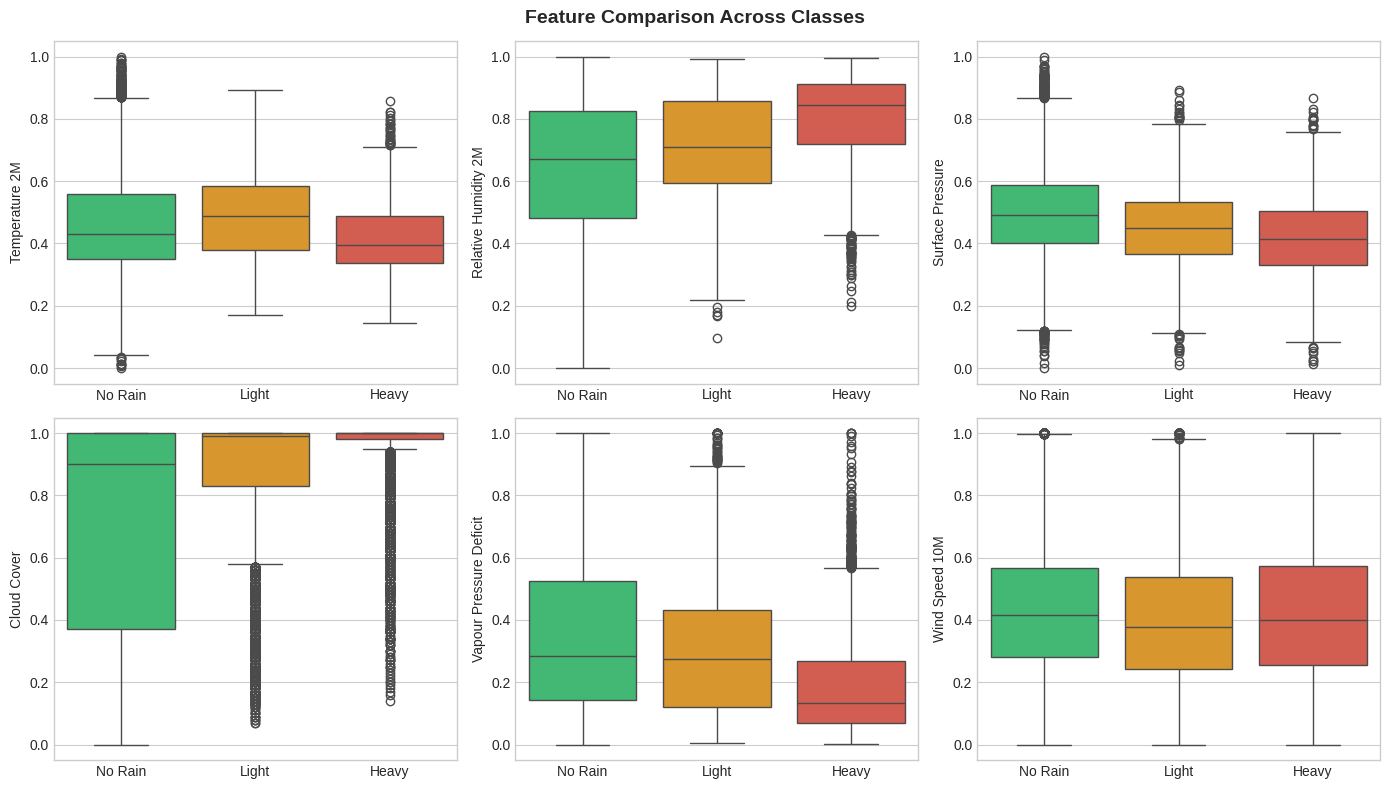

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, col in enumerate(features):
    ax = axes[idx]
    sns.boxplot(data=df, x='rain_class', y=col, ax=ax, palette=COLORS)
    ax.set_xticklabels(['No Rain', 'Light', 'Heavy'])
    ax.set_xlabel('')
    ax.set_ylabel(col.replace('_', ' ').title())

plt.suptitle('Feature Comparison Across Classes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Correlation Analysis

Which features correlate with rain? Are there redundant features?

In [11]:
target_corr = df.drop('rain_class', axis=1).corrwith(df['rain_class']).sort_values(key=abs, ascending=False)

print("Top 15 correlations with rain_class:")
print("-" * 45)
for feat, corr in target_corr.head(15).items():
    direction = "+" if corr > 0 else "-"
    print(f"{direction} {feat:35s} {abs(corr):.4f}")

Top 15 correlations with rain_class:
---------------------------------------------
+ weather_code                        0.9484
+ cloud_cover_mid                     0.4192
+ soil_moisture_0_to_7cm              0.4165
+ cloud_cover_low                     0.3792
+ dew_point_2m                        0.3290
+ temp_humidity                       0.3226
+ soil_moisture_7_to_28cm             0.2960
+ cloud_cover                         0.2698
+ relative_humidity_2m                0.2593
- temp_diff                           0.2492
+ cloud_cover_high                    0.2366
+ relative_humidity_2m_roll3          0.2244
+ relative_humidity_2m_roll6          0.2244
- vapour_pressure_deficit             0.2206
- surface_pressure                    0.1988


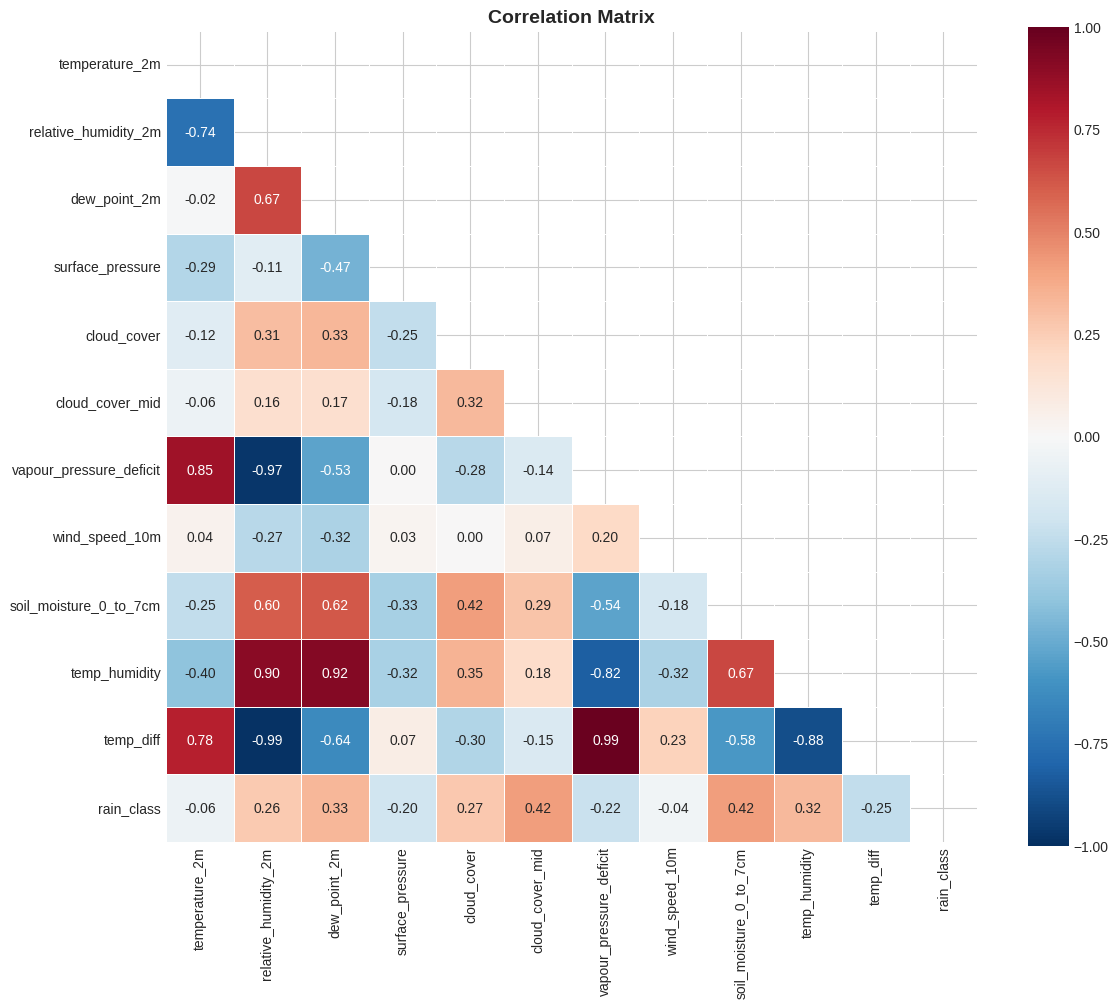

In [12]:
key_cols = ['temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'surface_pressure',
            'cloud_cover', 'cloud_cover_mid', 'vapour_pressure_deficit', 'wind_speed_10m',
            'soil_moisture_0_to_7cm', 'temp_humidity', 'temp_diff', 'rain_class']

corr_matrix = df[key_cols].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Important findings:
- weather_code has 0.95 correlation with target - this is suspicious and might be data leakage
- High multicollinearity between temperature features
- humidity and vapour_pressure_deficit are strongly negatively correlated

## 6. Temporal Patterns

When does it rain? Time of day? Season?

In [13]:
df['hour_actual'] = (df['hour'] * 23).round().astype(int)
df['month_actual'] = (df['month'] * 11 + 1).round().astype(int)
df['dow_actual'] = (df['day_of_week'] * 6).round().astype(int)

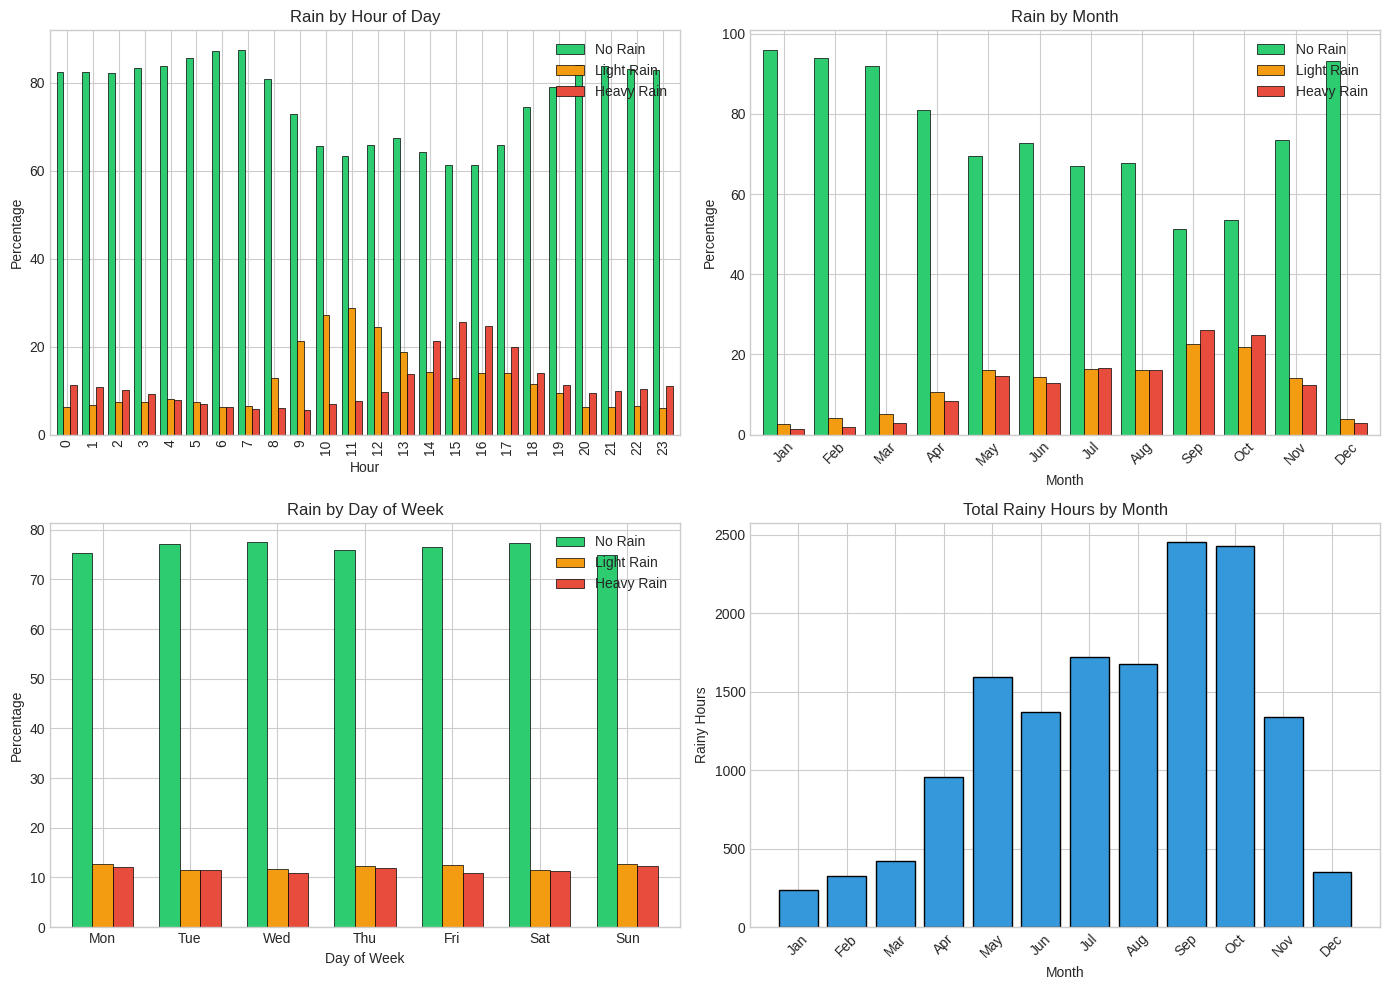

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Hourly
hourly = df.groupby(['hour_actual', 'rain_class']).size().unstack(fill_value=0)
hourly_pct = hourly.div(hourly.sum(axis=1), axis=0) * 100
hourly_pct.plot(kind='bar', ax=axes[0,0], color=COLORS, width=0.8, edgecolor='black', linewidth=0.5)
axes[0,0].set_xlabel('Hour')
axes[0,0].set_ylabel('Percentage')
axes[0,0].set_title('Rain by Hour of Day')
axes[0,0].legend([LABELS[i] for i in [0,1,2]], loc='upper right')

# Monthly
monthly = df.groupby(['month_actual', 'rain_class']).size().unstack(fill_value=0)
monthly_pct = monthly.div(monthly.sum(axis=1), axis=0) * 100
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_pct.plot(kind='bar', ax=axes[0,1], color=COLORS, width=0.8, edgecolor='black', linewidth=0.5)
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Percentage')
axes[0,1].set_title('Rain by Month')
axes[0,1].set_xticklabels(month_names, rotation=45)
axes[0,1].legend([LABELS[i] for i in [0,1,2]], loc='upper right')

# Day of week
dow = df.groupby(['dow_actual', 'rain_class']).size().unstack(fill_value=0)
dow_pct = dow.div(dow.sum(axis=1), axis=0) * 100
dow_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_pct.plot(kind='bar', ax=axes[1,0], color=COLORS, width=0.7, edgecolor='black', linewidth=0.5)
axes[1,0].set_xlabel('Day of Week')
axes[1,0].set_ylabel('Percentage')
axes[1,0].set_title('Rain by Day of Week')
axes[1,0].set_xticklabels(dow_names, rotation=0)
axes[1,0].legend([LABELS[i] for i in [0,1,2]], loc='upper right')

# Monthly rain count
monthly_rain = df[df['rain_class'] > 0].groupby('month_actual').size()
axes[1,1].bar(monthly_rain.index, monthly_rain.values, color='#3498db', edgecolor='black')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Rainy Hours')
axes[1,1].set_title('Total Rainy Hours by Month')
axes[1,1].set_xticks(range(1, 13))
axes[1,1].set_xticklabels(month_names, rotation=45)

plt.tight_layout()
plt.show()

Observations:
- Rain peaks in afternoon and evening hours
- Strong monsoon pattern from May to October
- Day of week doesn't matter (as expected - rain doesn't check the calendar)

## 7. Feature Means by Class

Simple comparison of average values.

In [15]:
compare_features = ['temperature_2m', 'relative_humidity_2m', 'cloud_cover',
                    'cloud_cover_mid', 'vapour_pressure_deficit', 'soil_moisture_0_to_7cm',
                    'surface_pressure', 'temp_diff']

means = df.groupby('rain_class')[compare_features].mean()
means.index = [LABELS[i] for i in means.index]
print(means.T.round(3))

                         No Rain  Light Rain  Heavy Rain
temperature_2m             0.457       0.484       0.417
relative_humidity_2m       0.642       0.714       0.808
cloud_cover                0.696       0.859       0.954
cloud_cover_mid            0.210       0.411       0.624
vapour_pressure_deficit    0.358       0.295       0.183
soil_moisture_0_to_7cm     0.453       0.688       0.785
surface_pressure           0.496       0.451       0.420
temp_diff                  0.283       0.216       0.138


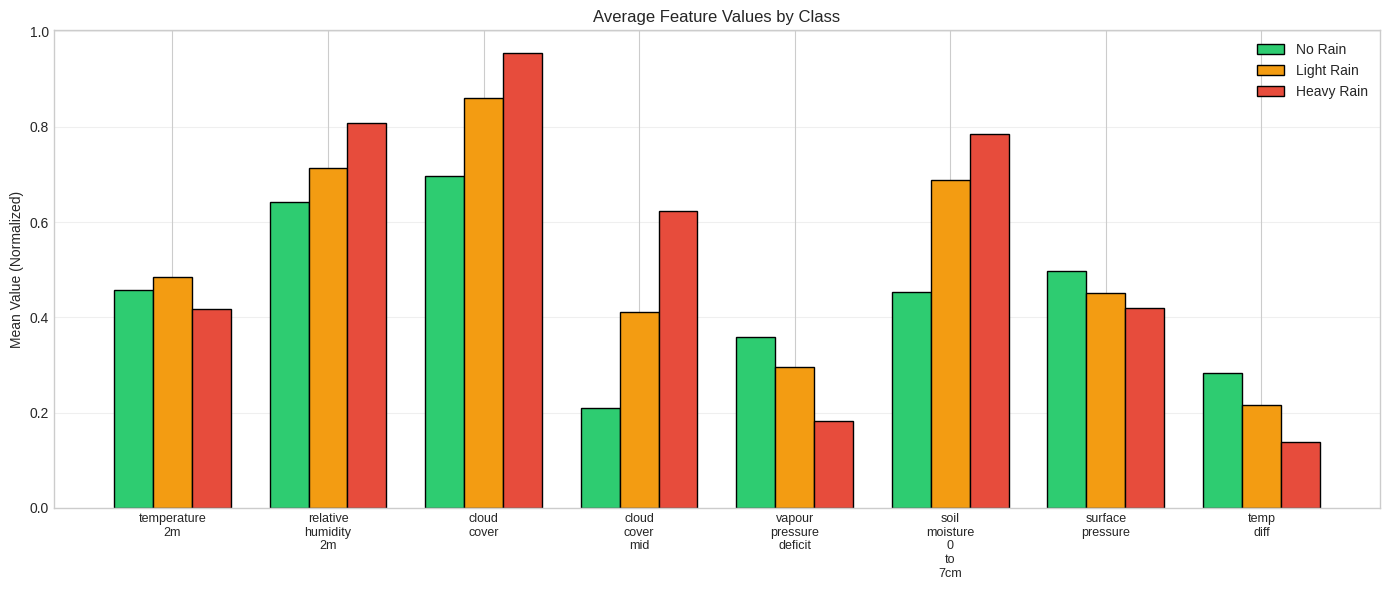

In [16]:
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(compare_features))
width = 0.25

for i, cls in enumerate([0, 1, 2]):
    values = df[df['rain_class'] == cls][compare_features].mean()
    ax.bar(x + i*width, values, width, label=LABELS[cls], color=COLORS[i], edgecolor='black')

ax.set_xticks(x + width)
ax.set_xticklabels([f.replace('_', '\n') for f in compare_features], fontsize=9)
ax.set_ylabel('Mean Value (Normalized)')
ax.set_title('Average Feature Values by Class')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Clear patterns:
- Humidity, cloud cover, soil moisture increase with rain
- Vapour pressure deficit, temp_diff, surface pressure decrease with rain

## 8. Feature Importance

Using mutual information and ANOVA to rank features.

In [17]:
X = df.drop(['rain_class', 'hour_actual', 'month_actual', 'dow_actual'], axis=1)
y = df['rain_class']

mi_scores = mutual_info_classif(X, y, random_state=42)
f_scores, _ = f_classif(X, y)

importance = pd.DataFrame({
    'feature': X.columns,
    'mutual_info': mi_scores,
    'f_score': f_scores
}).sort_values('mutual_info', ascending=False)

print("Top 15 Features by Mutual Information:")
print(importance.head(15).to_string(index=False))

Top 15 Features by Mutual Information:
                   feature  mutual_info      f_score
              weather_code     0.635834 3.882317e+06
    soil_moisture_0_to_7cm     0.137585 6.834183e+03
           cloud_cover_mid     0.102140 6.694449e+03
             temp_humidity     0.099429 3.755063e+03
              dew_point_2m     0.093982 4.285376e+03
           cloud_cover_low     0.081833 5.810459e+03
                     month     0.070027 1.178843e+03
          surface_pressure     0.064439 1.302619e+03
               cloud_cover     0.063371 2.499055e+03
   soil_moisture_7_to_28cm     0.063018 3.197613e+03
      relative_humidity_2m     0.056274 2.272407e+03
   vapour_pressure_deficit     0.052197 1.635619e+03
                 temp_diff     0.049483 2.082584e+03
          cloud_cover_high     0.041696 1.861894e+03
relative_humidity_2m_roll6     0.039802 1.886048e+03


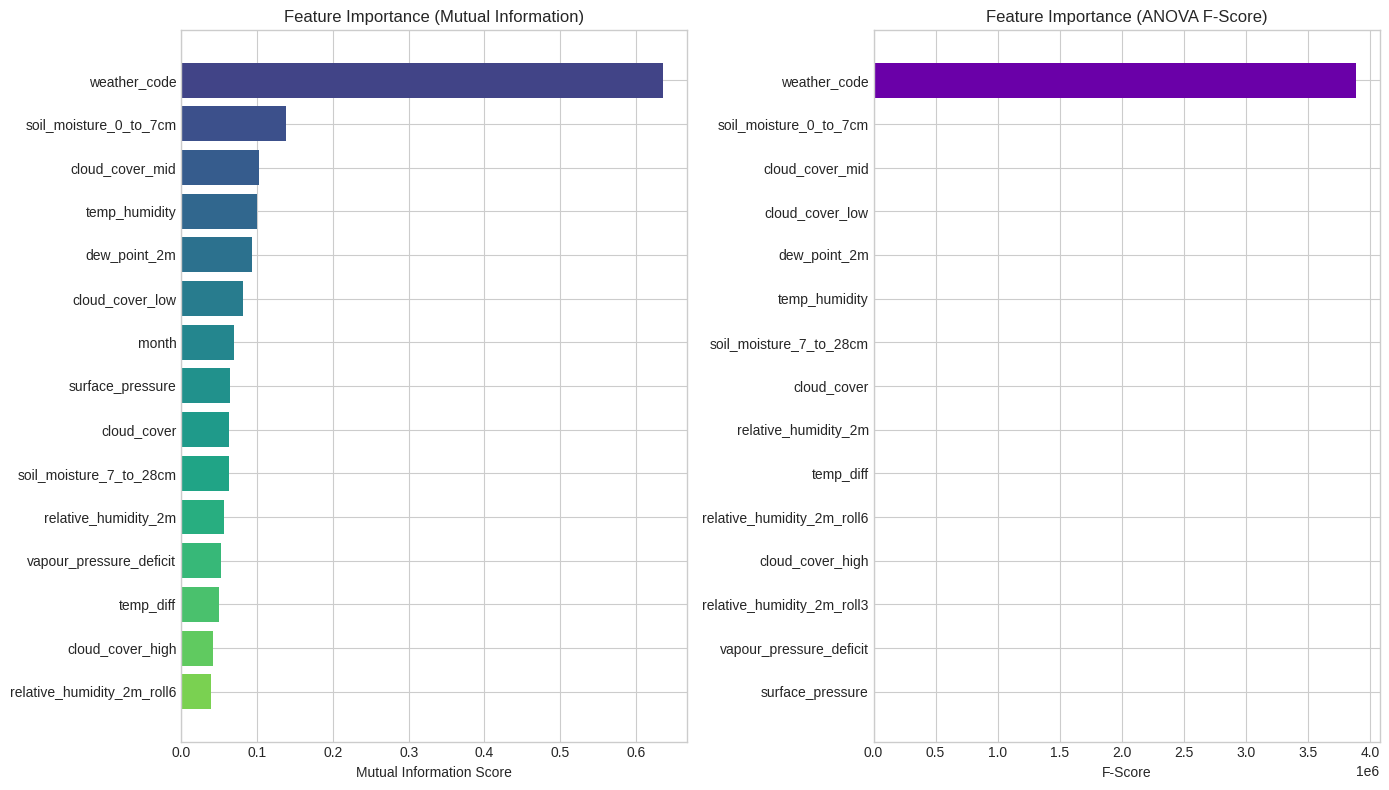

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

top_n = 15

# Mutual Information
top_mi = importance.head(top_n)
axes[0].barh(range(top_n), top_mi['mutual_info'].values, color=plt.cm.viridis(np.linspace(0.2, 0.8, top_n)))
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(top_mi['feature'].values)
axes[0].invert_yaxis()
axes[0].set_xlabel('Mutual Information Score')
axes[0].set_title('Feature Importance (Mutual Information)')

# F-score
top_f = importance.sort_values('f_score', ascending=False).head(top_n)
axes[1].barh(range(top_n), top_f['f_score'].values, color=plt.cm.plasma(np.linspace(0.2, 0.8, top_n)))
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(top_f['feature'].values)
axes[1].invert_yaxis()
axes[1].set_xlabel('F-Score')
axes[1].set_title('Feature Importance (ANOVA F-Score)')

plt.tight_layout()
plt.show()

## 9. Class Separation Scatter Plots

Can we visually separate the classes with feature pairs?

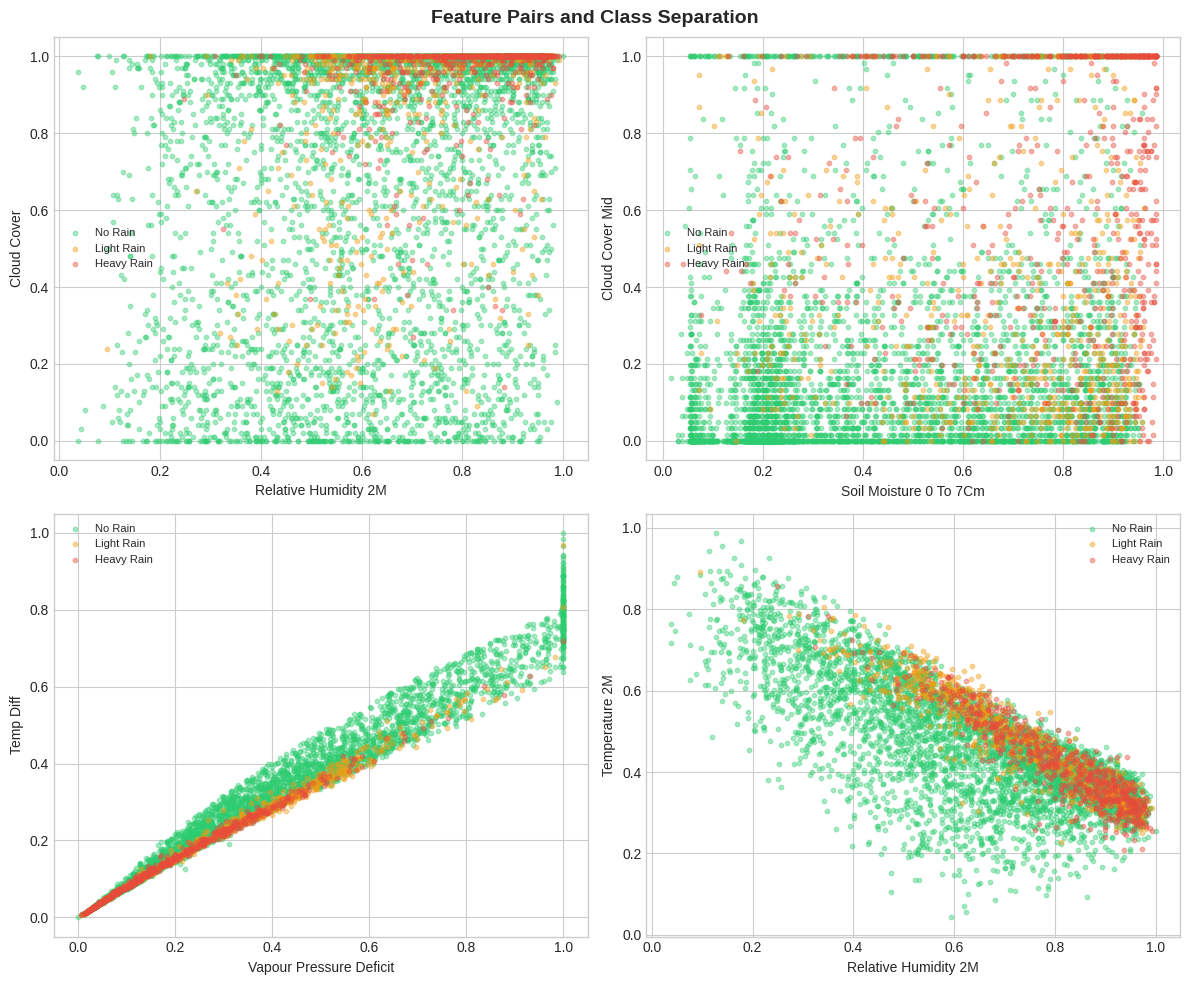

In [19]:
sample = df.sample(n=6000, random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

pairs = [
    ('relative_humidity_2m', 'cloud_cover'),
    ('soil_moisture_0_to_7cm', 'cloud_cover_mid'),
    ('vapour_pressure_deficit', 'temp_diff'),
    ('relative_humidity_2m', 'temperature_2m')
]

for idx, (x_col, y_col) in enumerate(pairs):
    ax = axes[idx // 2, idx % 2]
    for cls in [0, 1, 2]:
        data = sample[sample['rain_class'] == cls]
        ax.scatter(data[x_col], data[y_col], c=COLORS[cls], label=LABELS[cls], alpha=0.4, s=10)
    ax.set_xlabel(x_col.replace('_', ' ').title())
    ax.set_ylabel(y_col.replace('_', ' ').title())
    ax.legend(fontsize=8)

plt.suptitle('Feature Pairs and Class Separation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Summary and Recommendations

In [20]:
print("="*60)
print("EDA SUMMARY")
print("="*60)

print("\nDataset:")
print(f"  - {len(df):,} samples, {len(df.columns)} features")
print(f"  - No missing values or duplicates")
print(f"  - All features normalized to [0, 1]")

print("\nClass Imbalance:")
print(f"  - No Rain: 76.3% | Light Rain: 12.2% | Heavy Rain: 11.5%")
print(f"  - Imbalance ratio: 6.6x")
print(f"  - Action: Use SMOTE or class_weight='balanced'")

print("\nTop Predictive Features:")
print(f"  - weather_code (0.95 corr - check for leakage!)")
print(f"  - soil_moisture_0_to_7cm")
print(f"  - cloud_cover_mid")
print(f"  - relative_humidity_2m")

print("\nPotential Issues:")
print(f"  - weather_code correlation is suspiciously high")
print(f"  - High multicollinearity among temperature features")
print(f"  - Rolling features may leak future information")

print("\nRecommendations:")
print(f"  1. Investigate weather_code before using it")
print(f"  2. Use stratified or time-based train/test split")
print(f"  3. Handle class imbalance with SMOTE")
print(f"  4. Try Random Forest or XGBoost")
print(f"  5. Use F1-score as the evaluation metric")

EDA SUMMARY

Dataset:
  - 62,808 samples, 43 features
  - No missing values or duplicates
  - All features normalized to [0, 1]

Class Imbalance:
  - No Rain: 76.3% | Light Rain: 12.2% | Heavy Rain: 11.5%
  - Imbalance ratio: 6.6x
  - Action: Use SMOTE or class_weight='balanced'

Top Predictive Features:
  - weather_code (0.95 corr - check for leakage!)
  - soil_moisture_0_to_7cm
  - cloud_cover_mid
  - relative_humidity_2m

Potential Issues:
  - weather_code correlation is suspiciously high
  - High multicollinearity among temperature features
  - Rolling features may leak future information

Recommendations:
  1. Investigate weather_code before using it
  2. Use stratified or time-based train/test split
  3. Handle class imbalance with SMOTE
  4. Try Random Forest or XGBoost
  5. Use F1-score as the evaluation metric


In [21]:
# Clean up temporary columns
df.drop(['hour_actual', 'month_actual', 'dow_actual'], axis=1, inplace=True)